In [12]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, degree
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

KNN_K = 10
TARGET_COL = "Energy_Consumption_kWh"
META_COLS = ["vehicle_id", "timestamp"]
ARTIFACTS_DIR = os.path.join("..", "artifacts")
PROCESSED_DIR  = os.path.join("..", "data", "processed")

KNN_GRAPH_COLS = ["speed_kmh", "length", "gradient"]


## Data Loading

Processed CSVs produced by the Preprocessing Pipeline notebook are loaded from `energy-model/data/processed/`. `FEATURE_COLS` is inferred from headers, excluding target and metadata.

In [13]:
train_path = os.path.join(PROCESSED_DIR, "train_processed.csv")
val_path   = os.path.join(PROCESSED_DIR, "val_processed.csv")
test_path  = os.path.join(PROCESSED_DIR, "test_processed.csv")

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

EXCLUDE_COLS = [TARGET_COL] + META_COLS
FEATURE_COLS = [c for c in df_train.columns if c not in EXCLUDE_COLS]

X_train = df_train[FEATURE_COLS].values.astype("float32")
y_train = df_train[TARGET_COL].values.astype("float32")
X_val = df_val[FEATURE_COLS].values.astype("float32")
y_val = df_val[TARGET_COL].values.astype("float32")
X_test = df_test[FEATURE_COLS].values.astype("float32")
y_test = df_test[TARGET_COL].values.astype("float32")

knn_feat_idx = [FEATURE_COLS.index(c) for c in KNN_GRAPH_COLS]

print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"\nkNN graph columns: {KNN_GRAPH_COLS}")
print(f"kNN feature indices: {knn_feat_idx}")
print(f"\nSplit sizes:")
print(f"Train: X={X_train.shape}  y={y_train.shape}")
print(f"Val: X={X_val.shape}  y={y_val.shape}")
print(f"Test: X={X_test.shape}  y={y_test.shape}")

Feature columns (17): ['length', 'gradient', 'temperature', 'wind_speed', 'speed_kmh', 'battery_soc', 'acceleration', 'surface_type', 'traffic_density', 'weather_condition', 'gradient_sq', 'length_x_gradient', 'cold_penalty', 'wind_speed_sq', 'speed_sq', 'power_proxy', 'speed_x_length']

kNN graph columns: ['speed_kmh', 'length', 'gradient']
kNN feature indices: [4, 0, 1]

Split sizes:
Train: X=(3500, 17)  y=(3500,)
Val: X=(750, 17)  y=(750,)
Test: X=(750, 17)  y=(750,)


## k-NN Graph Construction

`build_knn_graph` fits a NearestNeighbors model on `X_knn` — the 3-feature
subset of `speed_kmh`, `length`, and `gradient`. Nodes nearby in this space
share similar energy regimes. GCNConv aggregating over these neighbours
provides real context — neighbouring segments have similar speed profiles,
comparable distances, and similar grade resistance.

In [14]:
def build_knn_graph(X_knn: np.ndarray, k: int) -> np.ndarray:
    t_start = time.time()
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric="euclidean", n_jobs=-1)
    nbrs.fit(X_knn)
    _, indices = nbrs.kneighbors(X_knn)

    src = np.repeat(np.arange(len(X_knn), dtype=np.int64), k)
    dst = indices[:, 1:].reshape(-1).astype(np.int64)
    edge_index = np.vstack([src, dst])

    print(f"k-NN: {len(X_knn)} nodes  k={k}  directed edges={len(src)} "
          f"({time.time() - t_start:.2f}s)")
    return edge_index

## PyG Data Object Construction

`build_pyg_data` takes the full 17-dim node feature matrix `X` and the
3-dim kNN space `X_knn` separately. The graph is made undirected then
self-loops are inserted — self-loops ensure each node attends to its
own features during aggregation, enabling inductive inference on the
OSMnx road graph at deployment.

In [15]:
def build_pyg_data(X: np.ndarray, X_knn: np.ndarray, y: np.ndarray, k: int) -> Data:
    N = len(X)

    edge_index_np = build_knn_graph(X_knn, k)
    edge_index_t = torch.from_numpy(edge_index_np).long()

    # to_undirected return type varies across PyG versions
    result = to_undirected(edge_index_t, num_nodes=N)
    edge_index_t = result[0] if isinstance(result, tuple) else result

    edge_attr_t = torch.ones(edge_index_t.shape[1], 1, dtype=torch.float32)

    self_idx = torch.arange(N, dtype=torch.long)
    sl_edge_idx = torch.stack([self_idx, self_idx], dim=0)
    sl_edge_attr = torch.zeros(N, 1, dtype=torch.float32)

    edge_index_t = torch.cat([edge_index_t, sl_edge_idx], dim=1)
    edge_attr_t  = torch.cat([edge_attr_t,  sl_edge_attr], dim=0)

    return Data(
        x = torch.from_numpy(X).float(),
        edge_index = edge_index_t,
        edge_attr = edge_attr_t,
        y = torch.from_numpy(y).float(),
    )

## Building Train / Val / Test Graphs

Each split receives its own independent kNN graph to prevent cross-split leakage.

In [16]:
X_train_knn = X_train[:, knn_feat_idx]
X_val_knn   = X_val[:, knn_feat_idx]
X_test_knn  = X_test[:, knn_feat_idx]

print("Building PyG Data objects...")
train_data = build_pyg_data(X_train, X_train_knn, y_train, k=KNN_K)
val_data   = build_pyg_data(X_val,   X_val_knn,   y_val,   k=KNN_K)
test_data  = build_pyg_data(X_test,  X_test_knn,  y_test,  k=KNN_K)

for split, data in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    print(f"\n{split}:")
    print(f"x shape: {tuple(data.x.shape)}")
    print(f"edge_index: {tuple(data.edge_index.shape)}")
    print(f"y shape: {tuple(data.y.shape)}")
    print(f"num_nodes: {data.num_nodes}")
    print(f"num_edges: {data.num_edges}")

Building PyG Data objects...
k-NN: 3500 nodes  k=10  directed edges=35000 (0.05s)
k-NN: 750 nodes  k=10  directed edges=7500 (0.02s)
k-NN: 750 nodes  k=10  directed edges=7500 (0.04s)

Train:
x shape: (3500, 17)
edge_index: (2, 44248)
y shape: (3500,)
num_nodes: 3500
num_edges: 44248

Val:
x shape: (750, 17)
edge_index: (2, 9664)
y shape: (750,)
num_nodes: 750
num_edges: 9664

Test:
x shape: (750, 17)
edge_index: (2, 9616)
y shape: (750,)
num_nodes: 750
num_edges: 9616


## Graph Statistics & Degree Distribution

       Nodes  kNN Edges  Self-loops  Avg Degree  Min Degree  Max Degree
Split                                                                  
Train   3500      40748        3500     11.6400          10          19
Val      750       8914         750     11.8900          10          22
Test     750       8866         750     11.8200          10          19


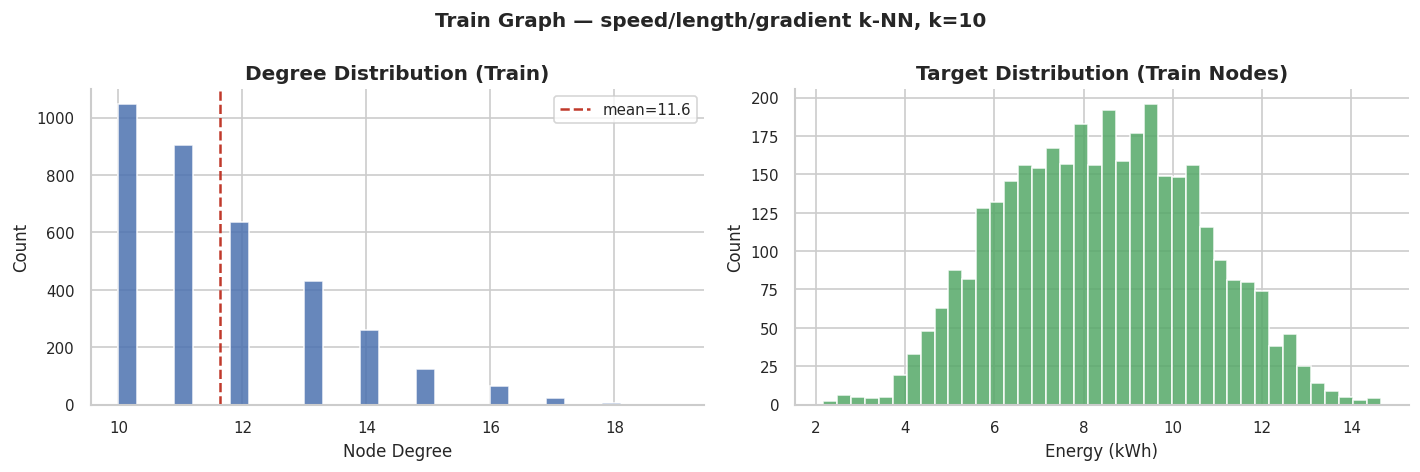

In [17]:
def compute_graph_stats(data: Data, name: str) -> dict:
    N        = data.num_nodes
    sl_mask  = data.edge_index[0] != data.edge_index[1]
    n_knn    = sl_mask.sum().item()
    knn_idx  = data.edge_index[:, sl_mask]
    deg      = degree(knn_idx[1], num_nodes=N).numpy()
    return {
        "Split"      : name,
        "Nodes"      : N,
        "kNN Edges"  : n_knn,
        "Self-loops" : data.num_edges - n_knn,
        "Avg Degree" : round(float(deg.mean()), 2),
        "Min Degree" : int(deg.min()),
        "Max Degree" : int(deg.max()),
    }

rows = [compute_graph_stats(d, n)
        for d, n in [(train_data, "Train"), (val_data, "Val"), (test_data, "Test")]]
stats_df = pd.DataFrame(rows).set_index("Split")
print(stats_df.to_string())

sl_mask_train = train_data.edge_index[0] != train_data.edge_index[1]
knn_idx_train = train_data.edge_index[:, sl_mask_train]
deg_train     = degree(knn_idx_train[1], num_nodes=train_data.num_nodes).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(deg_train, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(deg_train.mean(), color="#c0392b", linestyle="--", linewidth=1.5,
                label=f"mean={deg_train.mean():.1f}")
axes[0].set_title("Degree Distribution (Train)", fontweight="bold")
axes[0].set_xlabel("Node Degree")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=9)

axes[1].hist(train_data.y.numpy(), bins=40, color="#55A868", edgecolor="white", alpha=0.85)
axes[1].set_title("Target Distribution (Train Nodes)", fontweight="bold")
axes[1].set_xlabel("Energy (kWh)")
axes[1].set_ylabel("Count")

plt.suptitle(f"Train Graph — speed/length/gradient k-NN, k={KNN_K}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Leakage Verification

In [18]:
for split, data in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    max_idx = data.edge_index.max().item()
    assert max_idx < data.num_nodes, (
        f"{split}: edge_index out of bounds ({max_idx} >= {data.num_nodes})"
    )
    print(f"  {split:<6}: {data.num_nodes} nodes  edge_index max={max_idx}  OK")

print("\nAll graphs are self-contained -- no cross-split edges.")

  Train : 3500 nodes  edge_index max=3499  OK
  Val   : 750 nodes  edge_index max=749  OK
  Test  : 750 nodes  edge_index max=749  OK

All graphs are self-contained -- no cross-split edges.


## Graph Structure Visualisation

A 200-node subgraph is rendered with NetworkX. Nodes are coloured by energy
target (left) and degree (right). Clusters of similar-energy nodes confirm
that speed/length/gradient neighbourhood groups segments with comparable
energy profiles — the key property that gives GCNConv its advantage.

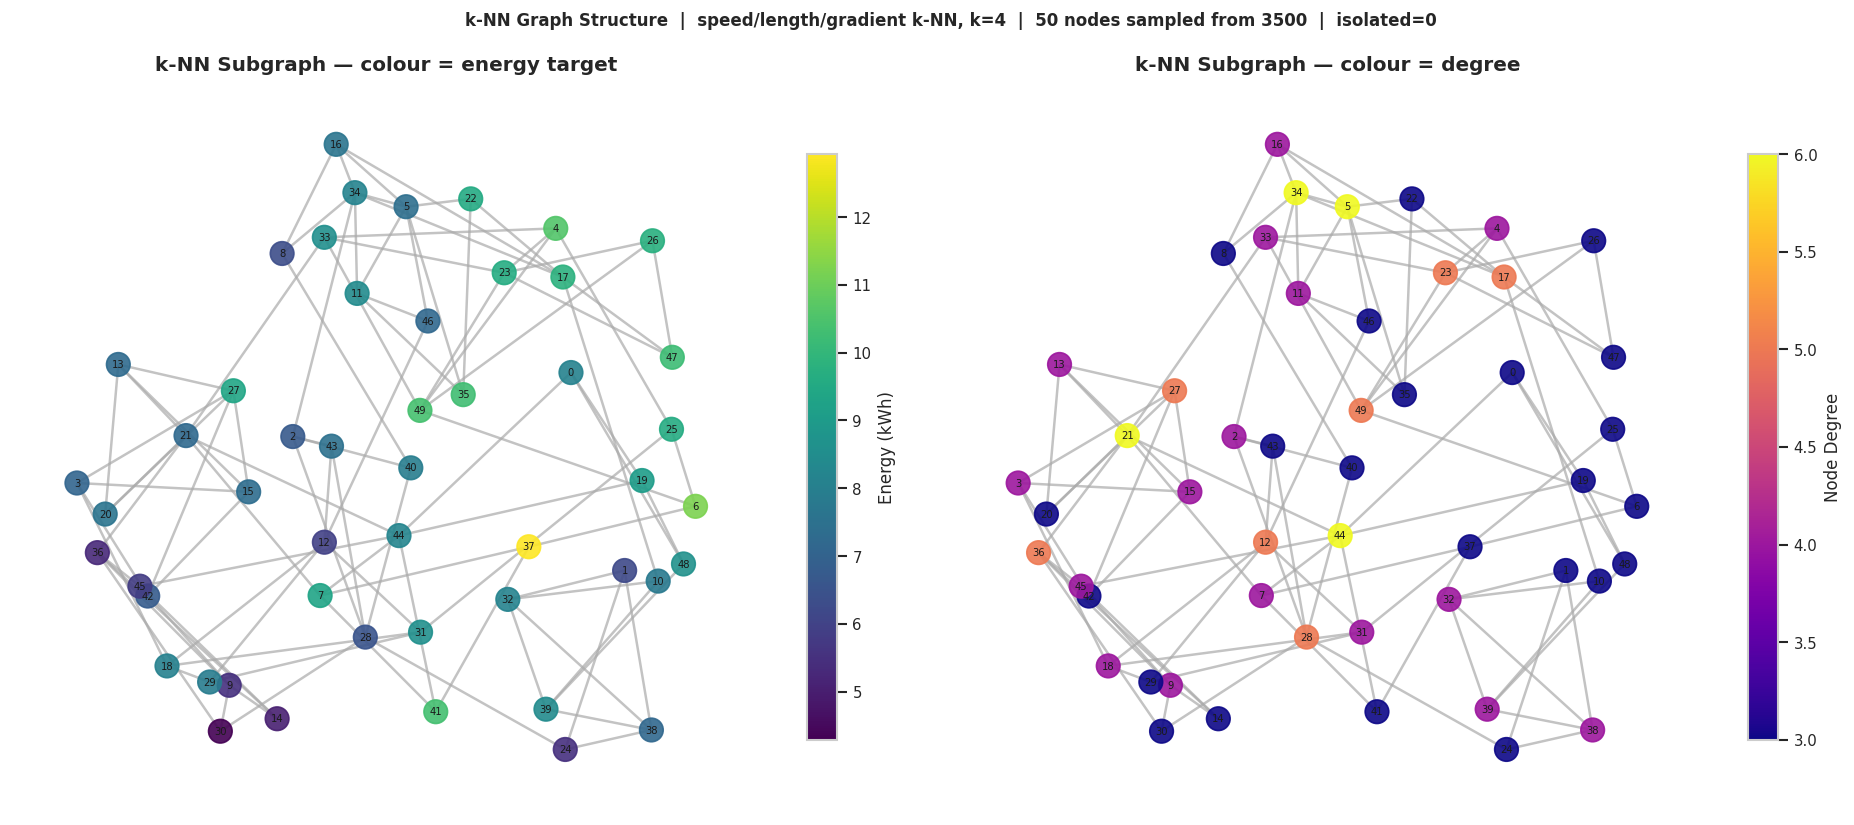

Sampled nodes: 50
Subgraph edges: 96
Isolated: 0/50
Avg degree: 3.84


In [19]:
N_VIZ = 50
rng = np.random.default_rng(42)
selected = rng.choice(train_data.num_nodes, size=N_VIZ, replace=False)
selected = sorted(selected.tolist())

X_viz = train_data.x[selected, :].cpu().numpy()
X_viz_knn = X_viz[:, [FEATURE_COLS.index(c) for c in ["speed_kmh", "length", "gradient"]]]

nbrs = NearestNeighbors(n_neighbors=4, metric="euclidean").fit(X_viz_knn)
_, indices = nbrs.kneighbors(X_viz_knn)

G = nx.Graph()
G.add_nodes_from(range(N_VIZ))
for i, neighbors in enumerate(indices):
    for j in neighbors:
        if i != j:
            G.add_edge(i, j)

y_sub = train_data.y[selected].cpu().numpy()
y_norm = (y_sub - y_sub.min()) / (y_sub.max() - y_sub.min() + 1e-8)
node_degrees = np.array([G.degree(n) for n in range(N_VIZ)])
isolated = sum(1 for n in G.nodes if G.degree(n) == 0)

pos = nx.spring_layout(G, k=0.8, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=y_norm,
                       cmap=plt.cm.viridis, node_size=200, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#aaaaaa", alpha=0.7, width=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=6)
plt.colorbar(plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(y_sub.min(), y_sub.max())
), ax=ax, label="Energy (kWh)", shrink=0.8)
ax.set_title("k-NN Subgraph — colour = energy target", fontweight="bold")
ax.axis("off")

ax = axes[1]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_degrees,
                       cmap=plt.cm.plasma, node_size=200, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#aaaaaa", alpha=0.7, width=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=6)
plt.colorbar(plt.cm.ScalarMappable(
    cmap=plt.cm.plasma,
    norm=plt.Normalize(node_degrees.min(), node_degrees.max())
), ax=ax, label="Node Degree", shrink=0.8)
ax.set_title("k-NN Subgraph — colour = degree", fontweight="bold")
ax.axis("off")

plt.suptitle(
    f"k-NN Graph Structure  |  speed/length/gradient k-NN, k=4  |  "
    f"{N_VIZ} nodes sampled from {train_data.num_nodes}  |  isolated={isolated}",
    fontsize=10, fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"Sampled nodes: {N_VIZ}")
print(f"Subgraph edges: {G.number_of_edges()}")
print(f"Isolated: {isolated}/{N_VIZ}")
print(f"Avg degree: {np.mean(node_degrees):.2f}")

## Dataset Export

In [20]:
graph_dataset = {
    "train": train_data,
    "val": val_data,
    "test": test_data,
    "meta": {
        "k": KNN_K,
        "feature_cols": FEATURE_COLS,
        "knn_graph_cols": KNN_GRAPH_COLS,
        "target_col": TARGET_COL,
        "node_feature_dim": len(FEATURE_COLS),
    },
}

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
save_path = os.path.join(ARTIFACTS_DIR, "graph_dataset.pt")
torch.save(graph_dataset, save_path)

size_mb = os.path.getsize(save_path) / 1024**2
print(f"Saved:{save_path} ({size_mb:.2f} MB)")

loaded = torch.load(save_path, weights_only=False)
print(f"Keys: {list(loaded.keys())}")
print(f"Meta: {loaded['meta']}")
print(f"Train x: {tuple(loaded['train'].x.shape)}")

Saved:../artifacts/graph_dataset.pt (1.56 MB)
Keys: ['train', 'val', 'test', 'meta']
Meta: {'k': 10, 'feature_cols': ['length', 'gradient', 'temperature', 'wind_speed', 'speed_kmh', 'battery_soc', 'acceleration', 'surface_type', 'traffic_density', 'weather_condition', 'gradient_sq', 'length_x_gradient', 'cold_penalty', 'wind_speed_sq', 'speed_sq', 'power_proxy', 'speed_x_length'], 'knn_graph_cols': ['speed_kmh', 'length', 'gradient'], 'target_col': 'Energy_Consumption_kWh', 'node_feature_dim': 17}
Train x: (3500, 17)


## Dataset Export

The three PyG `Data` objects are bundled with metadata and saved to `energy-model/artifacts/graph_dataset.pt`. NB4 (GCN training) loads this file directly.

In [21]:
summary = {
    "graph_type": f"speed/length/gradient k-NN (k={KNN_K}), undirected + self-loops",
    "knn_cols": KNN_GRAPH_COLS,
    "node_feature_dim": len(FEATURE_COLS),
    "train_nodes": train_data.num_nodes,
    "val_nodes": val_data.num_nodes,
    "test_nodes": test_data.num_nodes,
    "train_edges": train_data.num_edges,
    "artifact": os.path.join(ARTIFACTS_DIR, "graph_dataset.pt"),
}

print("=" * 62)
print("GRAPH CONSTRUCTION SUMMARY")
print("=" * 62)
for k, v in summary.items():
    print(f"  {k}: {v}")
print("=" * 62)
print("\nHandoff to: EV Energy -- GCN Training & Evaluation with PyTorch")
print(f"Node x dim: {len(FEATURE_COLS)}")
print(f"kNN on 3 cols: {KNN_GRAPH_COLS}")
print(f"add_self_loops: False in GCNConv (pre-added here)")

GRAPH CONSTRUCTION SUMMARY
  graph_type: speed/length/gradient k-NN (k=10), undirected + self-loops
  knn_cols: ['speed_kmh', 'length', 'gradient']
  node_feature_dim: 17
  train_nodes: 3500
  val_nodes: 750
  test_nodes: 750
  train_edges: 44248
  artifact: ../artifacts/graph_dataset.pt

Handoff to: EV Energy -- GCN Training & Evaluation with PyTorch
Node x dim: 17
kNN on 3 cols: ['speed_kmh', 'length', 'gradient']
add_self_loops: False in GCNConv (pre-added here)
